# Ayam Serayu - Monthly Revenue Forecasting (ANN)

In [ ]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.initializers import HeNormal, GlorotUniform
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
!kaggle datasets download bertnardomariouskono/serayu-chicken-time-series-and-forecasting-3-yrs

Dataset URL: https://www.kaggle.com/datasets/bertnardomariouskono/serayu-chicken-time-series-and-forecasting-3-yrs
License(s): apache-2.0
serayu-chicken-time-series-and-forecasting-3-yrs.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -q /content/serayu-chicken-time-series-and-forecasting-3-yrs.zip


replace AyamSerayu_3Years_Transaction_Data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


## 1. Load data

In [ ]:
df_ayam = pd.read_csv("AyamSerayu_3Years_Transaction_Data.csv")
df_ayam.head()

,Tanggal & Waktu,ID Struk,Outlet,Tipe Penjualan,Kasir,Nama Produk,Kategori,Jumlah Produk,Harga Produk,Penjualan Kotor,Total,Metode Pembayaran,Status Pembayaran,Diskon,Pajak
0,2023-01-01 00:51:19,TRX-20230101-8589,AYAM SERAYU - CABANG 2,Dine in,Rina,Ayam Bakar Madu,Makanan,1,31000,31000,36000,Tunai,Success,0,0
1,2023-01-01 00:51:19,TRX-20230101-8589,AYAM SERAYU - CABANG 2,Dine in,Rina,Air Mineral,Minuman,1,5000,5000,36000,QRIS,Success,0,0
2,2023-01-01 03:33:08,TRX-20230101-3069,AYAM SERAYU - PUSAT,Dine in,Budi,Cah Kangkung,Makanan,1,12000,12000,162000,QRIS,Success,0,0
3,2023-01-01 03:33:08,TRX-20230101-3069,AYAM SERAYU - PUSAT,Dine in,Budi,Kulit Ayam Crispy,Makanan,1,19000,19000,162000,Tunai,Success,0,0
4,2023-01-01 03:33:08,TRX-20230101-3069,AYAM SERAYU - PUSAT,Dine in,Budi,Lele Crispy,Makanan,2,20000,40000,162000,Debit,Success,0,0


In [ ]:
df_ayam

,Tanggal & Waktu,ID Struk,Outlet,Tipe Penjualan,Kasir,Nama Produk,Kategori,Jumlah Produk,Harga Produk,Penjualan Kotor,Total,Metode Pembayaran,Status Pembayaran,Diskon,Pajak
0,2023-01-01 00:51:19,TRX-20230101-8589,AYAM SERAYU - CABANG 2,Dine in,Rina,Ayam Bakar Madu,Makanan,1,31000,31000,36000,Tunai,Success,0,0
1,2023-01-01 00:51:19,TRX-20230101-8589,AYAM SERAYU - CABANG 2,Dine in,Rina,Air Mineral,Minuman,1,5000,5000,36000,QRIS,Success,0,0
2,2023-01-01 03:33:08,TRX-20230101-3069,AYAM SERAYU - PUSAT,Dine in,Budi,Cah Kangkung,Makanan,1,12000,12000,162000,QRIS,Success,0,0
3,2023-01-01 03:33:08,TRX-20230101-3069,AYAM SERAYU - PUSAT,Dine in,Budi,Kulit Ayam Crispy,Makanan,1,19000,19000,162000,Tunai,Success,0,0
4,2023-01-01 03:33:08,TRX-20230101-3069,AYAM SERAYU - PUSAT,Dine in,Budi,Lele Crispy,Makanan,2,20000,40000,162000,Debit,Success,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
626306,2025-12-31 23:10:57,TRX-20251231-5641,AYAM SERAYU - CABANG 1,Dine in,Nabila,Nasi Uduk,Makanan,1,7000,7000,59000,Tunai,Success,0,0
626307,2025-12-31 23:10:57,TRX-20251231-5641,AYAM SERAYU - CABANG 1,Dine in,Nabila,Nasi Putih,Makanan,1,5000,5000,59000,QRIS,Success,0,0
626308,2025-12-31 23:10:57,TRX-20251231-5641,AYAM SERAYU - CABANG 1,Dine in,Nabila,Ayam Goreng Serayu - Dada,Makanan,1,29000,29000,59000,Debit,Success,0,0
626309,2025-12-31 23:10:57,TRX-20251231-5641,AYAM SERAYU - CABANG 1,Dine in,Nabila,Nasi Uduk,Makanan,1,7000,7000,59000,QRIS,Success,0,0


In [ ]:
df_ayam['Tanggal & Waktu'] = pd.to_datetime(df_ayam['Tanggal & Waktu'], errors='coerce')
df_ayam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626311 entries, 0 to 626310
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Tanggal & Waktu    626311 non-null  datetime64[ns]
 1   ID Struk           626311 non-null  object        
 2   Outlet             626311 non-null  object        
 3   Tipe Penjualan     626311 non-null  object        
 4   Kasir              626311 non-null  object        
 5   Nama Produk        626311 non-null  object        
 6   Kategori           626311 non-null  object        
 7   Jumlah Produk      626311 non-null  int64         
 8   Harga Produk       626311 non-null  int64         
 9   Penjualan Kotor    626311 non-null  int64         
 10  Total              626311 non-null  int64         
 11  Metode Pembayaran  626311 non-null  object        
 12  Status Pembayaran  626311 non-null  object        
 13  Diskon             626311 non-null  int64   

In [ ]:
df_ayam.describe()

,Tanggal & Waktu,Jumlah Produk,Harga Produk,Penjualan Kotor,Total,Diskon,Pajak
count,626311,626311.000000,626311.000000,626311.000000,626311.000000,626311.0,626311.0
mean,2024-08-12 19:18:13.808993536,1.251070,15948.257335,19953.947799,71198.120423,0.0,0.0
min,2023-01-01 00:51:19,1.000000,5000.000000,5000.000000,5000.000000,0.0,0.0
25%,2023-11-30 19:48:59,1.000000,6000.000000,7000.000000,41000.000000,0.0,0.0
50%,2024-08-31 18:23:56,1.000000,12000.000000,15000.000000,64000.000000,0.0,0.0
75%,2025-05-09 18:55:46,1.000000,25000.000000,29000.000000,95000.000000,0.0,0.0
max,2025-12-31 23:10:57,3.000000,35000.000000,105000.000000,317000.000000,0.0,0.0
std,NaN,0.536877,10117.521832,16221.796623,40614.103229,0.0,0.0


In [ ]:
# Drop columns we don't need for revenue forecasting
df_ayam = df_ayam.drop(columns=['Diskon', 'Pajak'], errors='ignore')
df_ayam.isnull().sum()

,0
Tanggal & Waktu,0
ID Struk,0
Outlet,0
Tipe Penjualan,0
Kasir,0
Nama Produk,0
Kategori,0
Jumlah Produk,0
Harga Produk,0
Penjualan Kotor,0


In [ ]:
df_ayam.shape

(626311, 13)

## 2. Clean up duplicates

Note: a transaction (one `ID Struk`) can have multiple rows, one per product line item.
That's expected and is NOT a duplicate to drop -- only drop fully identical rows.

In [ ]:
df_ayam.duplicated().sum()

np.int64(10416)

In [ ]:
df_ayam = df_ayam.drop_duplicates()
df_ayam.shape

(615895, 13)

## 3. EDA

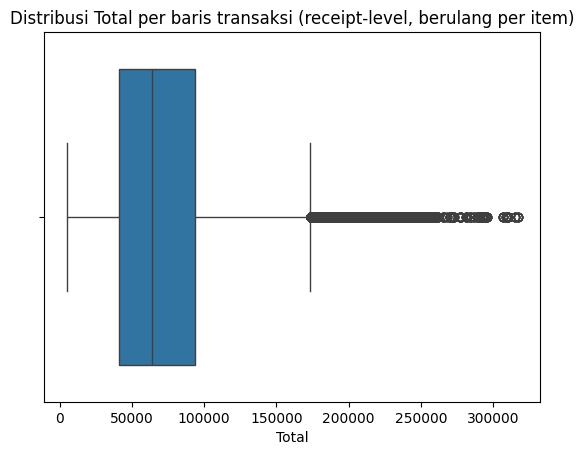

In [ ]:
sns.boxplot(x=df_ayam["Total"])
plt.title("Distribusi Total per baris transaksi (receipt-level, berulang per item)")
plt.show()

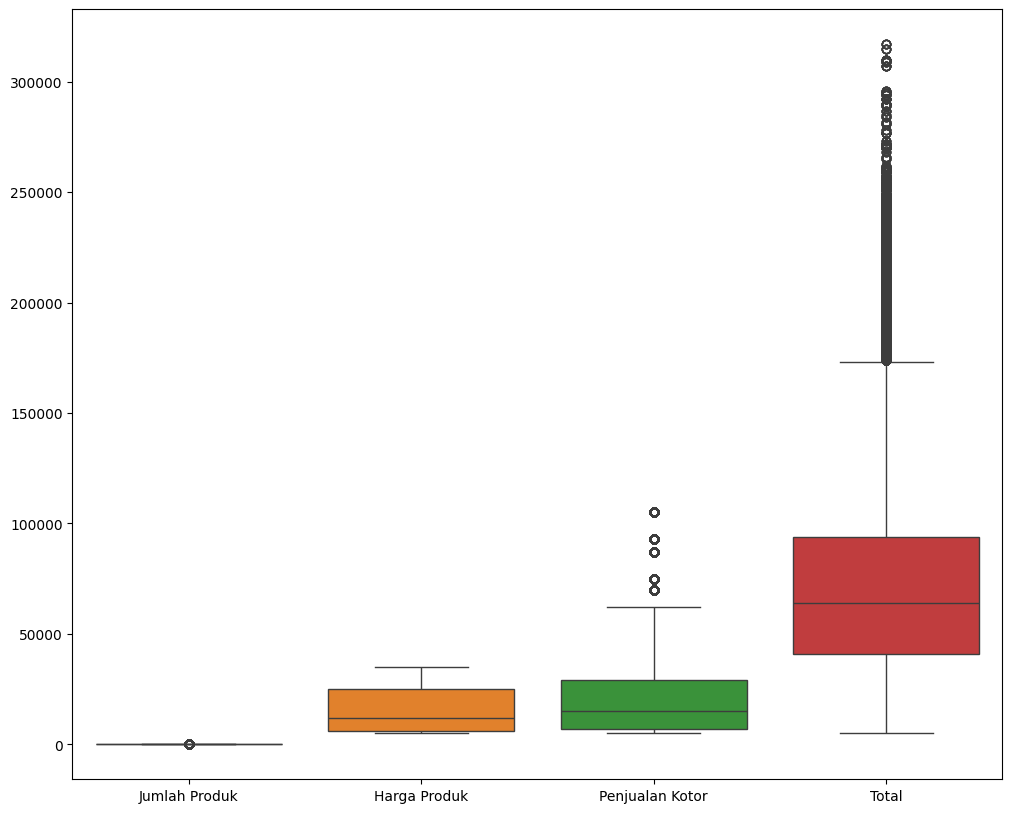

In [ ]:
numeric_cols = df_ayam.select_dtypes(include='number').columns

plt.figure(figsize=(12,10))
sns.boxplot(data=df_ayam[numeric_cols])
plt.show()

In [ ]:
Q1 = df_ayam["Total"].quantile(0.25)
Q3 = df_ayam["Total"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower: {lower}")
print(f"Upper: {upper}")

Lower: -38500.0
Upper: 173500.0


We are **not** dropping these "outliers" from `df_ayam`. At the transaction-line level, a high
`Total` just means a big receipt (e.g. a large dine-in order) -- it's a real, valid transaction,
not a data error. Removing it would silently delete real revenue before we aggregate to monthly
totals in the next step.

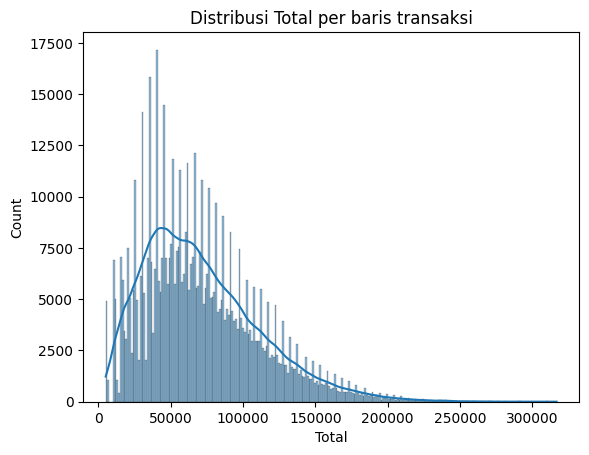

In [ ]:
sns.histplot(df_ayam['Total'], kde=True)
plt.title("Distribusi Total per baris transaksi")
plt.show()

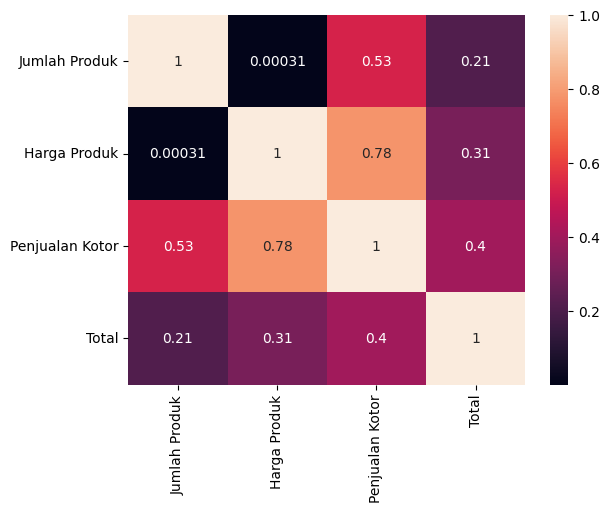

In [ ]:
num_cols = df_ayam.select_dtypes(include=np.number).columns
corr = df_ayam[num_cols].corr()
sns.heatmap(corr, annot=True)
plt.show()

## 4. Aggregate to monthly revenue per outlet

**Important fix**: `Total` is the *receipt* total, repeated on every product line item of that
receipt (a receipt with 3 items has the same `Total` on all 3 rows). Summing `Total` directly
over all rows (as in the original notebook) overcounts revenue by roughly the average number of
items per receipt (~3x here). We deduplicate by `ID Struk` first so each receipt is counted once,
*then* aggregate to monthly revenue.

In [ ]:
df_ayam = df_ayam.sort_values('Tanggal & Waktu').reset_index(drop=True)

# One row per receipt (Total is identical across all line items of a receipt)
receipts = df_ayam.drop_duplicates(subset=['ID Struk']).copy()

print("Baris transaksi (line items):", len(df_ayam))
print("Jumlah struk (receipts) unik :", len(receipts))

Baris transaksi (line items): 615895
Jumlah struk (receipts) unik : 206296


In [ ]:
df_revenue = (
    receipts.groupby([pd.Grouper(key='Tanggal & Waktu', freq='MS'), 'Outlet'])['Total']
    .sum()
    .reset_index()
    .rename(columns={'Tanggal & Waktu': 'bulan_tahun'})
)

df_revenue.head()

,bulan_tahun,Outlet,Total
0,2023-01-01,AYAM SERAYU - CABANG 1,92142000
1,2023-01-01,AYAM SERAYU - CABANG 2,87455000
2,2023-01-01,AYAM SERAYU - PUSAT,93158000
3,2023-02-01,AYAM SERAYU - CABANG 1,82106000
4,2023-02-01,AYAM SERAYU - CABANG 2,82632000


In [ ]:
df_revenue['bulan'] = df_revenue['bulan_tahun'].dt.month
df_revenue['tahun'] = df_revenue['bulan_tahun'].dt.year
df_revenue['quarter'] = df_revenue['bulan_tahun'].dt.quarter

## 5. Feature engineering: lag & rolling features

In [ ]:
df_revenue = df_revenue.sort_values(['Outlet', 'bulan_tahun']).reset_index(drop=True)

# lag_1 = total bulan sebelumnya
df_revenue['lag_1'] = df_revenue.groupby('Outlet')['Total'].shift(1)

# lag_3 = total 3 bulan sebelumnya
df_revenue['lag_3'] = df_revenue.groupby('Outlet')['Total'].shift(3)

# lag_6 = total 6 bulan sebelumnya
df_revenue['lag_6'] = df_revenue.groupby('Outlet')['Total'].shift(6)

# rolling_3 = rata-rata 3 bulan sebelumnya (tidak termasuk bulan ini, untuk menghindari leakage)
df_revenue['rolling_3'] = (
    df_revenue.groupby('Outlet')['Total'].shift(1).rolling(3).mean().reset_index(level=0, drop=True)
)

df_revenue.head(10)

,bulan_tahun,Outlet,Total,bulan,tahun,quarter,lag_1,lag_3,lag_6,rolling_3
0,2023-01-01,AYAM SERAYU - CABANG 1,92142000,1,2023,1,NaN,NaN,NaN,NaN
1,2023-02-01,AYAM SERAYU - CABANG 1,82106000,2,2023,1,92142000.0,NaN,NaN,NaN
2,2023-03-01,AYAM SERAYU - CABANG 1,90533000,3,2023,1,82106000.0,NaN,NaN,NaN
3,2023-04-01,AYAM SERAYU - CABANG 1,110510000,4,2023,2,90533000.0,92142000.0,NaN,8.826033e+07
4,2023-05-01,AYAM SERAYU - CABANG 1,110590000,5,2023,2,110510000.0,82106000.0,NaN,9.438300e+07
5,2023-06-01,AYAM SERAYU - CABANG 1,88906000,6,2023,2,110590000.0,90533000.0,NaN,1.038777e+08
6,2023-07-01,AYAM SERAYU - CABANG 1,94855000,7,2023,3,88906000.0,110510000.0,92142000.0,1.033353e+08
7,2023-08-01,AYAM SERAYU - CABANG 1,96269000,8,2023,3,94855000.0,110590000.0,82106000.0,9.811700e+07
8,2023-09-01,AYAM SERAYU - CABANG 1,94307000,9,2023,3,96269000.0,88906000.0,90533000.0,9.334333e+07
9,2023-10-01,AYAM SERAYU - CABANG 1,96351000,10,2023,4,94307000.0,94855000.0,110510000.0,9.514367e+07


In [ ]:
# Drop baris dengan NaN akibat lag/rolling (bulan-bulan awal tiap outlet)
df_revenue = df_revenue.dropna().reset_index(drop=True)
df_revenue.shape

(90, 10)

## 6. Encode outlet (one-hot)

Using a single `OneHotEncoder` fit once on the full feature set (not `pd.get_dummies` applied
separately to train/test -- that previously created mismatched/duplicate columns).

In [ ]:
encoder = OneHotEncoder(sparse_output=False)
outlet_encoded = encoder.fit_transform(df_revenue[['Outlet']])
outlet_df = pd.DataFrame(outlet_encoded, columns=encoder.get_feature_names_out(), index=df_revenue.index)

df_revenue = pd.concat([df_revenue, outlet_df], axis=1)
df_revenue.head()

,bulan_tahun,Outlet,Total,bulan,tahun,quarter,lag_1,lag_3,lag_6,rolling_3,Outlet_AYAM SERAYU - CABANG 1,Outlet_AYAM SERAYU - CABANG 2,Outlet_AYAM SERAYU - PUSAT
0,2023-07-01,AYAM SERAYU - CABANG 1,94855000,7,2023,3,88906000.0,110510000.0,92142000.0,1.033353e+08,1.0,0.0,0.0
1,2023-08-01,AYAM SERAYU - CABANG 1,96269000,8,2023,3,94855000.0,110590000.0,82106000.0,9.811700e+07,1.0,0.0,0.0
2,2023-09-01,AYAM SERAYU - CABANG 1,94307000,9,2023,3,96269000.0,88906000.0,90533000.0,9.334333e+07,1.0,0.0,0.0
3,2023-10-01,AYAM SERAYU - CABANG 1,96351000,10,2023,4,94307000.0,94855000.0,110510000.0,9.514367e+07,1.0,0.0,0.0
4,2023-11-01,AYAM SERAYU - CABANG 1,87762000,11,2023,4,96351000.0,96269000.0,110590000.0,9.564233e+07,1.0,0.0,0.0


## 7. Train/test split (chronological)

Time series data must be split by time, not shuffled -- otherwise the model "sees the future"
during training. We sort by date and take the last 20% of months (per the full sorted set) as
the test set.

In [ ]:
df_revenue = df_revenue.sort_values('bulan_tahun').reset_index(drop=True)

split_idx = int(len(df_revenue) * 0.8)
train = df_revenue.iloc[:split_idx].copy()
test = df_revenue.iloc[split_idx:].copy()

print("Train periode:", train['bulan_tahun'].min(), "-", train['bulan_tahun'].max())
print("Test periode :", test['bulan_tahun'].min(), "-", test['bulan_tahun'].max())
print("Train shape:", train.shape, " Test shape:", test.shape)

Train periode: 2023-07-01 00:00:00 - 2025-06-01 00:00:00
Test periode : 2025-07-01 00:00:00 - 2025-12-01 00:00:00
Train shape: (72, 13)  Test shape: (18, 13)


In [ ]:
feature_cols = [
    'bulan',
    'tahun',
    'quarter',
    'lag_1',
    'lag_3',
    'lag_6',
    'rolling_3',
] + list(encoder.get_feature_names_out())

X_train = train[feature_cols]
y_train = train['Total']

X_test = test[feature_cols]
y_test = test['Total']

print(X_train.shape, X_test.shape)

(72, 10) (18, 10)


## 8. Scale features and target

Both `X` and `y` need scaling for an ANN with `relu`/`linear` layers like this -- the original
notebook only scaled `y` and trained on an undefined `X_train_scaled`. Scalers are fit on
**train only** and applied to test (no leakage).

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

print("NaNs in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("NaNs in y_train_scaled:", np.isnan(y_train_scaled).sum())

NaNs in X_train_scaled: 0
NaNs in y_train_scaled: 0


In [ ]:
print(y_train.min())
print(y_train.max())
print(y_train.mean())

84899000
156803000
114905027.77777778


## 9. Build the ANN

Fixed the syntax error (stray comma before the first `Dense` unit count) and used one consistent
variable name, `model_ann`, throughout the rest of the notebook.

In [ ]:
model_ann = Sequential([
    Dense(
        24,
        activation='relu',
        kernel_initializer=HeNormal(),
        input_shape=(X_train_scaled.shape[1],)
    ),
    BatchNormalization(),
    Dropout(0.3),

    Dense(
        16,
        activation='relu',
        kernel_initializer=HeNormal()
    ),
    BatchNormalization(),
    Dropout(0.3),

    Dense(
        8,
        activation='relu',
        kernel_initializer=HeNormal()
    ),

    Dense(
        1,
        activation='linear',
        kernel_initializer=GlorotUniform()
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_ann.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 24)             │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24)             │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 969 (3.79 KB)

 Trainable params: 889 (3.47 KB)

 Non-trainable params: 80 (320.00 B)

## 10. Callbacks + training

`EarlyStopping`/`ModelCheckpoint` must be created *before* `.fit()` so they actually get used
(previously they were defined after training already happened, so they had no effect).

Note: with only ~70 training rows, a `batch_size=16` and `epochs=100` risks overfitting fast --
`EarlyStopping` on `val_loss` is doing real work here. If results still look unstable, also try
reducing model capacity further or using k-fold cross-validation instead of a single split,
given how little data this is.

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_ann.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model_ann.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - loss: 1.2915 - mae: 0.8384
Epoch 1: val_loss improved from None to 4.05578, saving model to best_ann.keras

Epoch 1: finished saving model to best_ann.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 1.6908 - mae: 1.0249 - val_loss: 4.0558 - val_mae: 1.7632
Epoch 2/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.2852 - mae: 0.9349
Epoch 2: val_loss improved from 4.05578 to 3.67885, saving model to best_ann.keras

Epoch 2: finished saving model to best_ann.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 1.3602 - mae: 0.9363 - val_loss: 3.6788 - val_mae: 1.6698
Epoch 3/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1.2790 - mae: 0.8838
Epoch 3: val_loss improved from 3.67885 to 3.28581, saving model to best_ann.keras

Epoch 3: finished saving model to best_ann.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1.5835 - mae: 1.0108 - val_loss: 3.2858 - val_mae: 1.5711
Epoch 4/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - los

In [ ]:
print(history.history['loss'][:10])
print(history.history['val_loss'][:10])

[1.6907784938812256, 1.3601725101470947, 1.583465814590454, 1.2066394090652466, 1.3306406736373901, 1.3099662065505981, 1.229745626449585, 1.2300204038619995, 0.9115636348724365, 0.9992242455482483]
[4.055784225463867, 3.6788461208343506, 3.2858054637908936, 2.9783074855804443, 2.690473794937134, 2.454296827316284, 2.2765562534332275, 2.1456713676452637, 2.021273612976074, 1.8998312950134277]


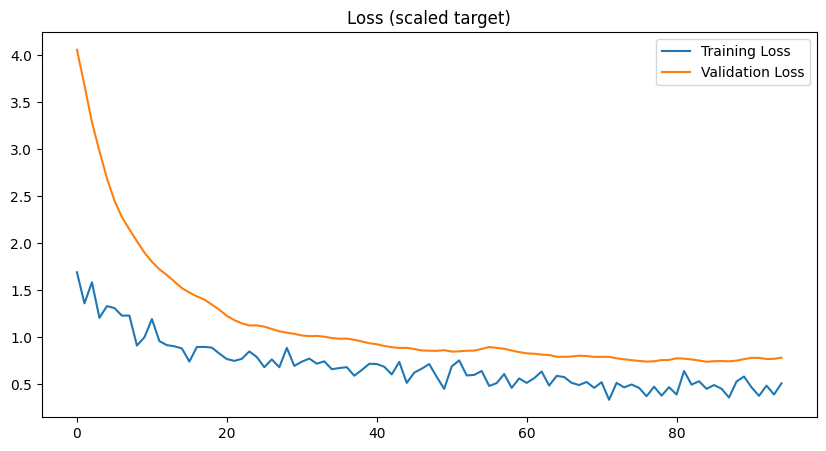

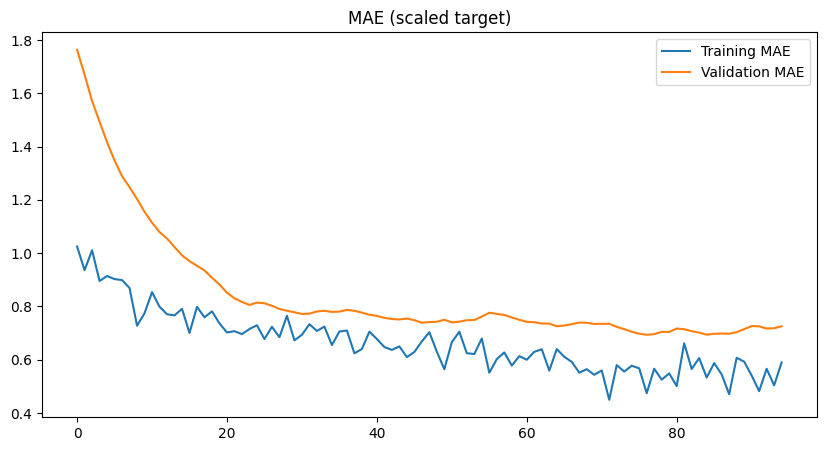

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss (scaled target)")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.legend()
plt.title("MAE (scaled target)")
plt.show()

## 11. Evaluate on test set (original Rupiah scale)

In [ ]:
y_pred_scaled = model_ann.predict(X_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
MAE : 12456820.0
RMSE: 15431568.42640488
R2  : -1.1989383697509766


## 12. Baseline comparison

With ~70 training rows total across 3 outlets, an ANN has very little signal to learn from.
A naive seasonal baseline (predict `lag_1`, i.e. "this month = last month") is a useful sanity
check -- if the ANN can't beat this, it isn't actually learning anything useful yet.

In [ ]:
baseline_pred = test['lag_1'].values

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Naive baseline (predict = last month's revenue)")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R2  :", baseline_r2)

print()
print("ANN vs baseline MAE improvement:", baseline_mae - mae)

Naive baseline (predict = last month's revenue)
MAE : 7911722.222222222
RMSE: 11959854.284229387
R2  : -0.32082347238466746

ANN vs baseline MAE improvement: -4545097.777777778


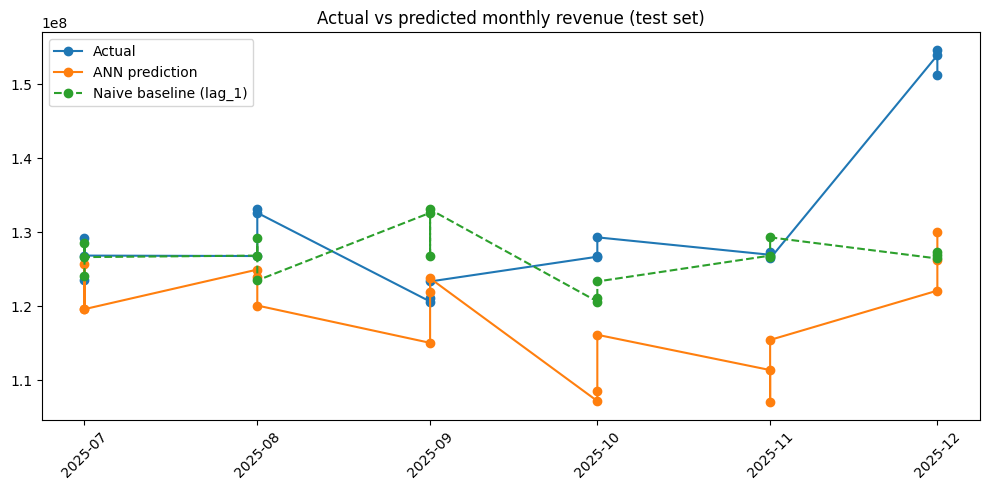

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(test['bulan_tahun'].values, y_test.values, marker='o', label='Actual')
plt.plot(test['bulan_tahun'].values, y_pred, marker='o', label='ANN prediction')
plt.plot(test['bulan_tahun'].values, baseline_pred, marker='o', linestyle='--', label='Naive baseline (lag_1)')
plt.legend()
plt.title("Actual vs predicted monthly revenue (test set)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. Save model + preprocessing pipeline

In [ ]:
model_ann.save("ann_model.keras")

pipeline = {
    "scaler": scaler,
    "y_scaler": y_scaler,
    "encoder": encoder,
    "feature_cols": feature_cols,
}
joblib.dump(pipeline, "ann_preprocessing_pipeline.joblib")

print("Saved ann_model.keras and ann_preprocessing_pipeline.joblib")

Saved ann_model.keras and ann_preprocessing_pipeline.joblib


*(Removed the old `files.download("prediction_ridge.joblib")` / Colab-only cell and the leftover
commented-out Ridge regression code -- they referenced a different model that isn't part of this
notebook. If you're running this in Colab and want to download the files, use:)*

```python
from google.colab import files
files.download("ann_model.keras")
files.download("ann_preprocessing_pipeline.joblib")
```